In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!gdown https://drive.google.com/uc?id=1Io_VRNN_euiDlQqgX2IQNTOXd3zWXe4X

Downloading...
From: https://drive.google.com/uc?id=1Io_VRNN_euiDlQqgX2IQNTOXd3zWXe4X
To: /content/aerofit_treadmill.csv
100% 7.28k/7.28k [00:00<00:00, 18.3MB/s]


In [ ]:
df = pd.read_csv('aerofit_treadmill.csv')

# **Basic checks on data**

In [ ]:
#data glimps check
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
#data information overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
# data shape check
df.shape

(180, 9)

In [ ]:
# datatype check for all columns
df.dtypes

,0
Product,object
Age,int64
Gender,object
Education,int64
MaritalStatus,object
Usage,int64
Fitness,int64
Income,int64
Miles,int64


In [ ]:
#Checking overall data patterns
df.describe(include='all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


There are 3 products, with KP281 being the most purchased (80 out of 180 customers, ~44%).

Young Customer Base : Average age: 28.8 years
Median age: 26 years
75% of customers are 33 years or younger

Male-Dominated Audience
104 males (58%) vs 76 females (42%)

Majority Are Partnered
107 customers (59%) are partnered

Moderate Product Usage
Average usage: 3.46 times per week
Most common usage: 3 times per week

Fitness Levels Are Mid-Range
Average fitness rating: 3.31
Majority fall between 3 and 4

Middle-to-Upper Income Segment
Average income: $53,720
Top 25% earn above $58,668
Max income: $104,581

Moderate Activity Levels (Miles)
Average miles: 103 miles
Median: 94 miles
Wide range: 21–360 miles


Observations from basic data check :
1. Data is in good shape having no null values & no correction, imputation required.
2. Data includes 3 types of unique products, 2 gender, 2 maritalstatuses.
3. 6 string type columns and 3 numeric type columns.
4. Product : KP281, Gender : Male, MaritalStatus : Partenered are top contributers to data.

# **Value counts and unique attributes**

In [ ]:
#Product Distribution
product_counts = round(df['Product'].value_counts(normalize=True)*100,2)
product_counts

,proportion
Product,
KP281,44.44
KP481,33.33
KP781,22.22


In [ ]:
#Gender Distribution
Gender_counts = round(df['Gender'].value_counts(normalize=True)*100,2)
Gender_counts

,proportion
Gender,
Male,57.78
Female,42.22


In [ ]:
#Marital Status Share
MaritalStatus_Count = round(df['MaritalStatus'].value_counts(normalize=True)*100,2)
MaritalStatus_Count

,proportion
MaritalStatus,
Partnered,59.44
Single,40.56


In [ ]:
product_summary = df.groupby('Product').agg(Avg_Age=('Age', 'mean'),Avg_Usage=('Usage', 'mean'),Avg_Fitness=('Fitness', 'mean'),Avg_Income=('Income', 'mean'),Avg_Miles=('Miles', 'mean')).reset_index()
product_summary = product_summary.round(2)
product_summary

,Product,Avg_Age,Avg_Usage,Avg_Fitness,Avg_Income,Avg_Miles
0,KP281,28.55,3.09,2.96,46418.02,82.79
1,KP481,28.90,3.07,2.90,48973.65,87.93
2,KP781,29.10,4.78,4.62,75441.58,166.90


Observations from value counts check :

1. Data includes 3 unique products with KP281 having highest contribution as 44% of total treadmill sales.
2. Data is divided in Male and Female gender with Male having 15% higher contribution to product purchase.
3. Partenered customers are puchasing trademills 48% more as compared to single customers.
4. While age remains consistent across segments, KP781 attracts significantly higher-income, higher-fitness, and high-mileage customers, confirming its premium performance positioning.
5. KP281 and KP481 serve the moderate-use segment with limited differentiation, suggesting potential repositioning opportunities.
6. Customers tend to buy KP781 with high Avg_Usage, high Avg_Fitness	high Avg_Income, high	Avg_Miles

# **Visual Analysis**

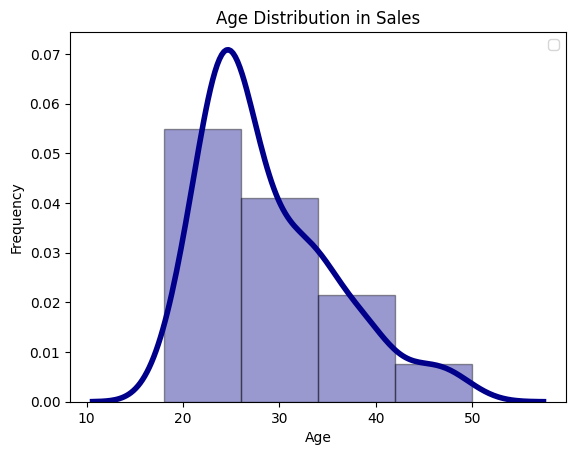

In [ ]:
sns.distplot(df['Age'], hist=True, kde=True,bins=4, color = 'darkblue',hist_kws={'edgecolor':'black'}
,kde_kws={'linewidth': 4})
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution in Sales')
plt.legend()
plt.show()

1. Most customers fall between 20–35 years age group.
2. Peak Age Group is around 24–28 years age.
3. Ages 45–50 have very low frequency
4. The distribution appears right skewed as Mean>Median and Long tail toward higher ages
5. P(20≤X≤35) is higher where P(X>40) is relatively small.

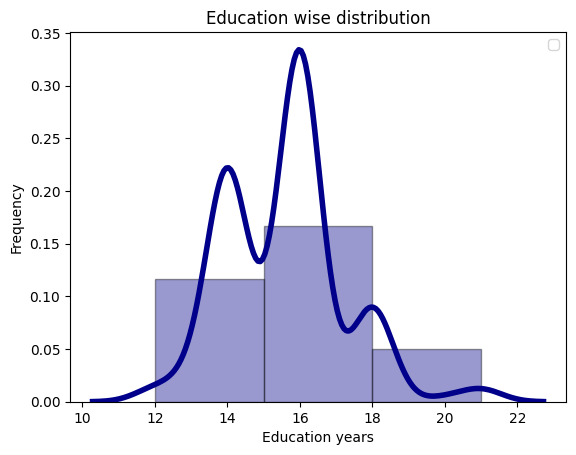

In [ ]:
sns.distplot(df['Education'], hist=True, kde=True,bins=3, color = 'darkblue',hist_kws={'edgecolor':'black'}
,kde_kws={'linewidth': 4})
plt.xlabel('Education years')
plt.ylabel('Frequency')
plt.title('Education wise distribution')
plt.legend()
plt.show()

1. Highest concentration around 16 years of education & noticeable group around 14 years
2. Very few customers with lower education below 13 levels.
3. Need to craft marketing messages aligned with educated, research-oriented buyers.

In [ ]:
bins = [17, 25, 35, 45, 50]
labels = ['18-25', '26-35', '36-45', '46-50']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,18-25
1,KP281,19,Male,15,Single,2,3,31836,75,18-25
2,KP281,19,Female,14,Partnered,4,3,30699,66,18-25
3,KP281,19,Male,12,Single,3,3,32973,85,18-25
4,KP281,20,Male,13,Partnered,4,2,35247,47,18-25


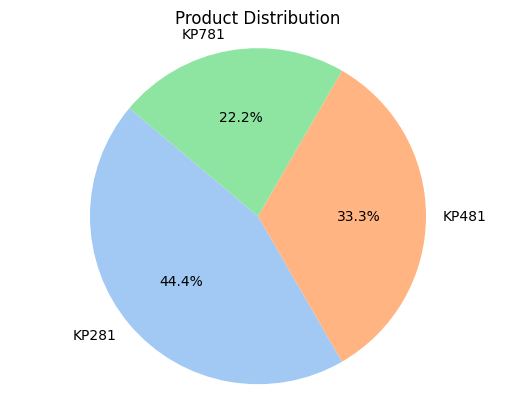

In [ ]:
colors = sns.color_palette('pastel')[0:len(product_counts)]
plt.pie(product_counts, labels=product_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Product Distribution')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular.
plt.show()

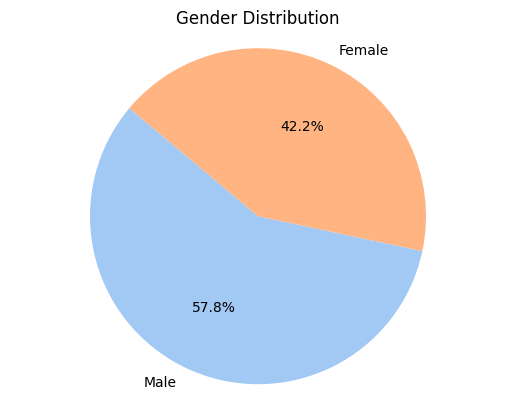

In [ ]:
plt.pie(Gender_counts, labels=Gender_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Gender Distribution')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular.
plt.show()

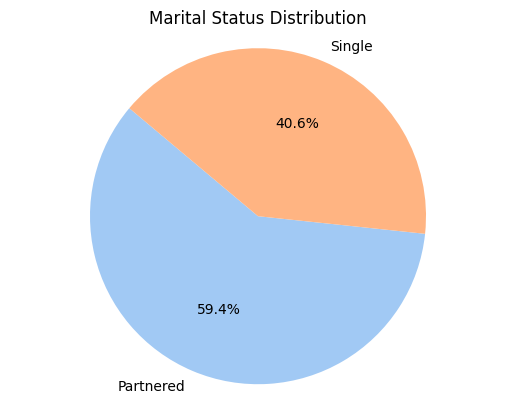

In [ ]:
plt.pie(MaritalStatus_Count, labels=MaritalStatus_Count.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Marital Status Distribution')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular.
plt.show()

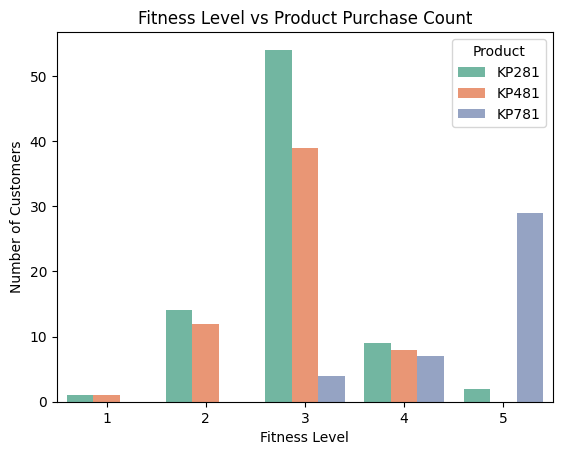

In [ ]:
sns.countplot(data=df, x='Fitness', hue='Product', palette='Set2')
plt.title('Fitness Level vs Product Purchase Count')
plt.xlabel('Fitness Level')
plt.ylabel('Number of Customers')
plt.show()

1. Most selling products KP281 and KP481 appeal mostly to customers with moderate fitness levels (2-4).
2. KP781 attracts primarily the most fit customers or highly active users.(Level 5).
3. The fitness level is a strong differentiator for product preference.

1. Marketing for KP781 should target highly fit individuals like athletes, fitness enthusiasts.
2. KP281 and KP481 should focus on moderately active customers.

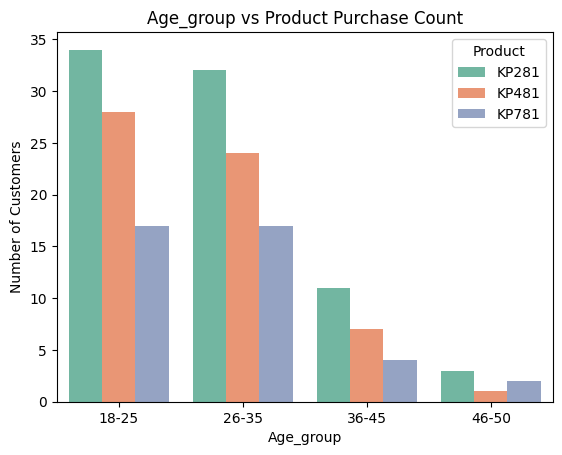

In [ ]:
sns.countplot(data=df, x='Age_Group', hue='Product', palette='Set2')
plt.title('Age_group vs Product Purchase Count')
plt.xlabel('Age_group')
plt.ylabel('Number of Customers')
plt.show()

1. KP281 has the highest sales in every age group.
2. The 18–35 group is the largest buyer segment. They account for the majority of total sales across all products.
3. Sales decrease significantly in age group above 35.
4. Marketing strategies must be designed with focus on youth.
5. Offer loyalty programs to retain young buyers.
6. Social media marketing and Student discounts can be used.

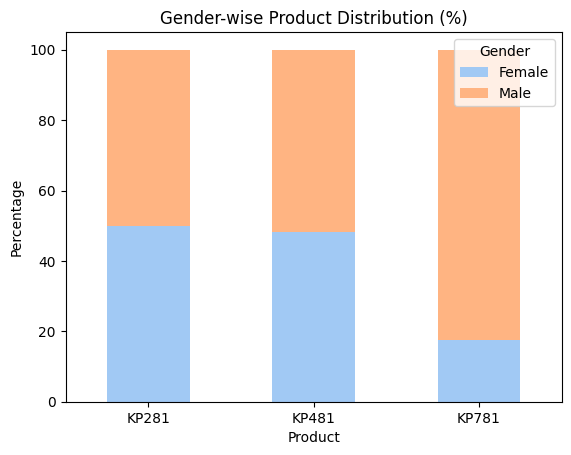

In [ ]:
gender_product_pct = pd.crosstab(df['Product'], df['Gender'], normalize='index') * 100
gender_product_pct.plot(kind='bar', stacked=True, color=colors)
plt.title('Gender-wise Product Distribution (%)')
plt.xlabel('Product')
plt.xticks(rotation=0)
plt.ylabel('Percentage')
plt.legend(title='Gender')
plt.show()

1. KP781 is a male-dominant premium product.
2. KP281 & KP481 are gender-neutral products.
3. KP781 has Potential to explore female-targeted campaigns or product tweaks.


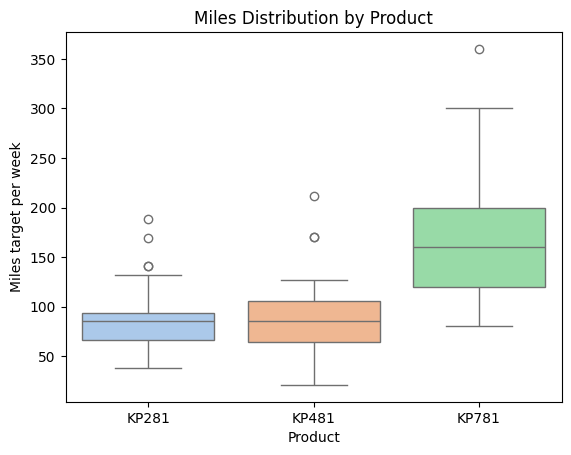

In [ ]:
sns.boxplot(data=df, x='Product', y='Miles', palette=colors)
plt.title('Miles Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Miles target per week')
plt.show()

1. KP781 has the highest median miles, significantly above KP281 and KP481.
2. KP781 shows the widest spread (highest variability), indicating diverse but intensive usage patterns.
3. KP281 and KP481 have similar median miles, with heavy overlap in distributions.
4. KP481 shows slightly more variability than KP281 but not a major shift in central tendency.
5. KP781 has higher extreme values (outliers), suggesting a segment of very high-mileage users.
6. Position KP781 for serious runners with endurance-focused features and advanced tracking capabilities.
7. Differentiate KP481 more clearly, as its mileage distribution overlaps heavily with KP281.
8. Introduce tiered performance programs or add-ons for high-mile KP781 users to increase retention and upsell opportunities.

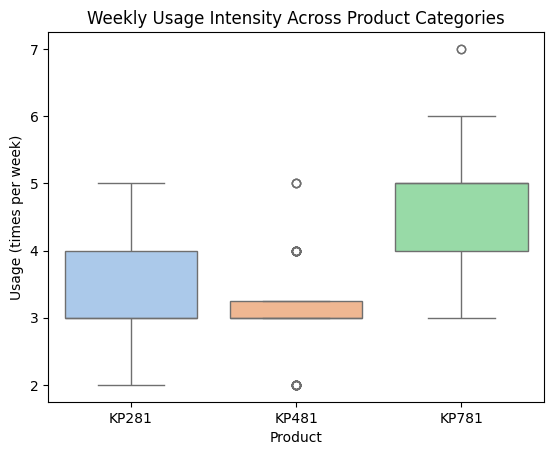

In [ ]:
sns.boxplot(data=df, x='Product', y='Usage', palette=colors)
plt.title('Weekly Usage Intensity Across Product Categories')
plt.xlabel('Product')
plt.ylabel('Usage (times per week)')
plt.show()

1. KP781 has the highest weekly usage, with a median around 4–5 times and peaks up to 7 times per week.
2. KP281 shows moderate usage, typically between 3 - 4 times weekly with relatively stable variation.
3. KP481 has the lowest median usage (~3 times per week) and a tighter central distribution.
4. KP781 exhibits greater variability, indicating stronger engagement among certain user segments.
5. Upsell & bundle KP781 with complementary products to maximize revenue from highly engaged users.
6. Boost KP481 engagement through targeted promotions, user education, or feature enhancements to increase frequency of use.
7. Stabilize KP281 growth by implementing loyalty incentives to shift moderate users toward higher weekly usage.

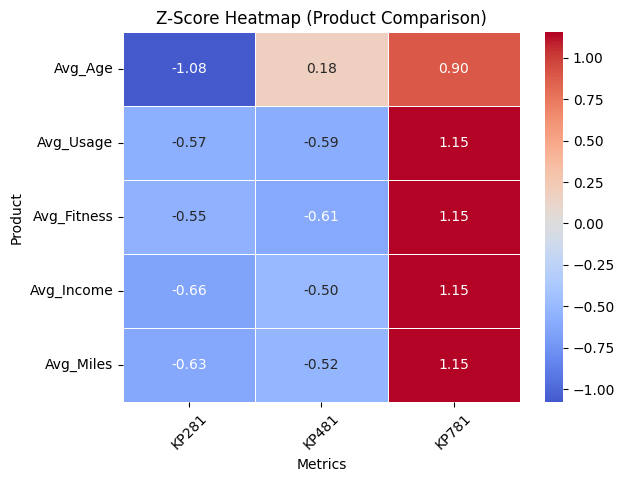

In [ ]:
zscore_df = product_summary.copy()

features = zscore_df.columns.drop("Product")

zscore_df[features] = (zscore_df[features] - zscore_df[features].mean()) / zscore_df[features].std()

zscore_df.set_index("Product", inplace=True)

sns.heatmap(zscore_df.T,annot=True,cmap="coolwarm",center=0,fmt=".2f",linewidths=0.5)

plt.title("Z-Score Heatmap (Product Comparison)")
plt.ylabel("Product")
plt.xlabel("Metrics")
plt.xticks(rotation=45)
plt.show()

1. KP781 strongly over-indexes on Usage, Fitness, Income, and Miles (~ +1.15), indicating a high-performance, high-income segment.
2. Age is not a major differentiator — differences are relatively small compared to other metrics.
3. KP281 underperforms across most metrics, especially Income and Engagement-related measures.
4. KP481 sits close to average but slightly below on performance indicators, showing weak differentiation.
5. Clear two-cluster structure emerges: KP781 (premium/high engagement) vs KP281 & KP481 (moderate/low engagement).


1. Strengthen premium positioning of KP781 through performance-focused marketing and value-added features.

2. Reposition KP481 to clearly differentiate it (either enhance features or adjust pricing).

3. Target KP281 toward entry-level customers with affordability-driven campaigns and beginner-focused messaging.

# **Missing Value & Outlier Detection**

**Missing Value Detection**
1. All columns show count = 180. So,No missing values detected.
2. No nulls in categorical variables (Product, Gender, Marital Status).
3. No nulls in numerical variables (Age, Income, Usage, Miles).
4. Dataset is clean for modeling.

**Outlier Detection**

Miles Outliers:
Extreme value around 360 miles.
Several points above 200 miles (especially KP781).

Usage Outliers:
Maximum usage = 7 times/week (likely KP781).
Some low-usage at 2 times/week.

Income Outlier:
Max income is 104,581 which is far above Q3(58,668)

Age Outlier:
Max age = 50, while majority under 35.

Education max = 21 years (possible postgraduate outlier).

Distribution spread suggests KP781 has highest variance.

**Missing value and outlier treatment**

No missing values detected (all variables count = 180).
No imputation required.

No impossible or invalid values detected.
No treatment required.

# **Business Insights based on Non-Graphical and Visual Analysis**

1. The product portfolio clearly splits into two segments: KP781 (premium, high engagement) and KP281/KP481 (moderate use mass segment).
2. KP781 customers have the highest usage, fitness levels, income, and miles, confirming strong premium positioning.
3. KP281 is the highest selling product (44%) but underperforms on engagement and income metrics.
4. KP481 shows heavy overlap with KP281 in usage, miles, and fitness, indicating weak differentiation.
5. The customer base is predominantly young (20–35 years), with peak buyers aged 24–28.
6. Sales decline significantly after age 35, and age is not a strong differentiator across products.
7. The audience is moderately male-skewed (58%) and majority partnered (59%).
8. Most customers are 14–16 years of education with middle to upper income levels.
9. KP781 has the highest variability and extreme high mile users, indicating a strong high value segment.
10. The fitness level and income are strong differentiator for product preference.

# **Recommendations**

1. Strengthen KP781’s premium positioning through performance focused branding and advanced feature messaging.
2. Clearly reposition KP481 either through feature enhancement or pricing strategy to avoid cannibalization.
3. Protect and monetize high mile KP781 users via add-ons, tiered programs, and bundled offerings.
4. Launch structured upgrade campaigns to convert KP281 users into KP781 buyers.
5. Focus marketing heavily on the 20 - 35 age segment using digital and social-first strategies.
6. Expand KP781’s reach among female customers through targeted campaigns and product adaptations.
7. Target KP281 toward entry level customers with affordability driven campaigns and beginner focused messaging